### ロボットの動き
+ 世界座標系

In [1]:
import matplotlib.pyplot as plt
%matplotlib inline

世界座標系クラス

In [2]:
class World:
    def __init__(self):
        self.objects = []

    def append(self, obj):
        self.objects.append(obj)

    def draw(self):
        fig = plt.figure(figsize=(8,8)) # 8x8 inch図
        ax = fig.add_subplot(111)
        ax.set_aspect('equal') # 縦横比を座標の値と一致させる
        ax.set_xlim(-5,5)
        ax.set_ylim(-5,5)
        ax.set_xlabel('X', fontsize=20)
        ax.set_ylabel('Y', fontsize=20)

        for obj in self.objects: obj.draw(ax) # 登録オブジェクトを順次描画

        plt.show()

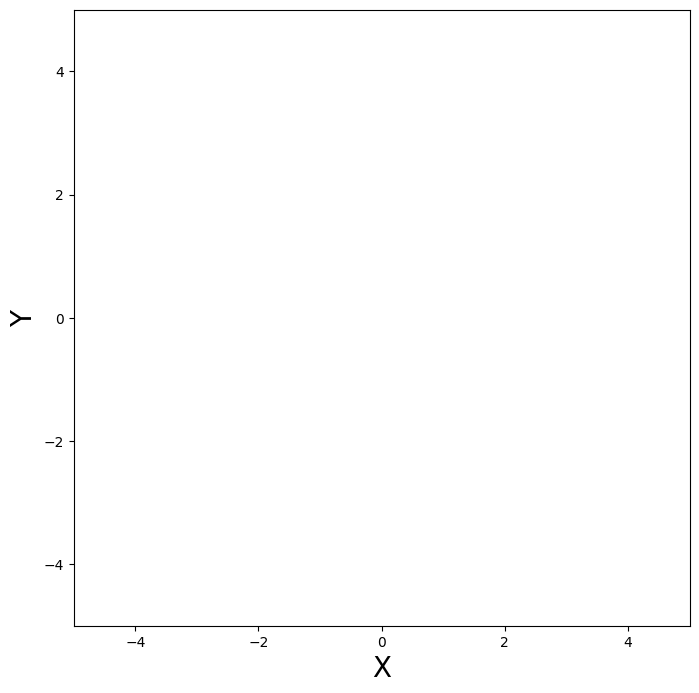

In [3]:
world = World()
world.draw()

### 姿勢=状態の定義と定義域
+ x : [x_min, x_max]
+ y : [y_min, y_max]
+ θ: [-π, +π] X軸正方向を0deg, 反時計まわりに正値

In [4]:
import matplotlib.pyplot as plt
import math
import matplotlib.patches as patches
import numpy as np

理想ロボットのクラス

In [5]:
class IdealRobot:
    def __init__(self, pose, color='black'):
        self.pose = pose
        self.r = 0.2 # 描画用のロボット半径
        self.color = color

    def draw(self, ax):
        x, y, theta = self.pose
        xn = x + self.r * math.cos(theta) # ロボット鼻先のX座標
        yn = y + self.r * math.sin(theta) # ロボット鼻先のY座標

        ax.plot([x,xn], [y,yn], color=self.color) # 鼻先ベクトル
        c = patches.Circle(xy=(x,y), radius=self.r, fill=False, color=self.color)
        ax.add_patch(c) # patches.Circleでロボットの胴体を示す円を作ってサブプロットへ登録

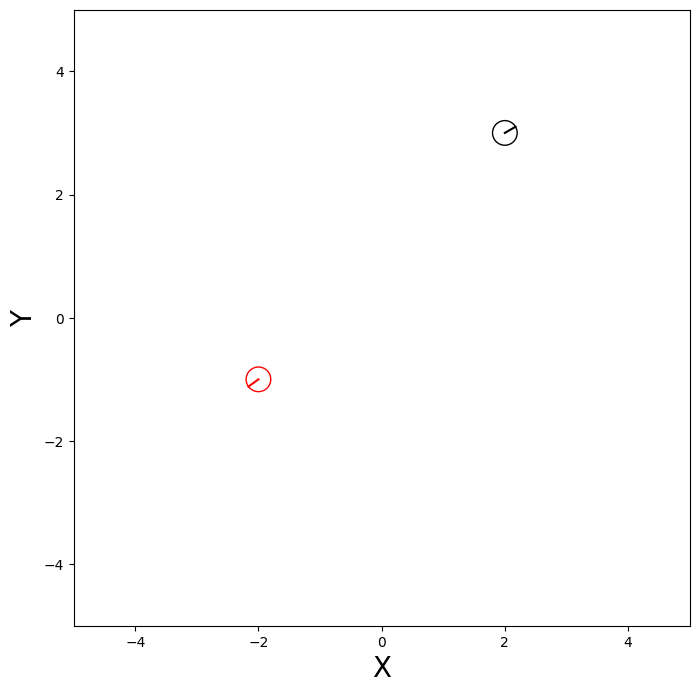

In [6]:
world = World()
robot1 = IdealRobot(pose=np.array([2, 3, math.pi/6]).T)
robot2 = IdealRobot(pose=np.array([-2, -1, math.pi/5 * 6]).T, color='red')
world.append(robot1)
world.append(robot2)
world.draw()

アニメーション

In [37]:
import matplotlib
matplotlib.use('nbagg')
import matplotlib.animation as anm
from IPython.display import HTML # NoteBookでmatplotlibのアニメーションを再生させる
%matplotlib notebook

In [51]:
class World:
    def __init__(self, debug=False):
        self.objects = []
        self.debug = debug

    def append(self, obj):
        self.objects.append(obj)

    def draw(self):
        fig = plt.figure(figsize=(4,4)) # 4x4 inch図
        ax = fig.add_subplot(111)
        ax.set_aspect('equal') # 縦横比を座標の値と一致させる
        ax.set_xlim(-5,5)
        ax.set_ylim(-5,5)
        ax.set_xlabel('X', fontsize=10)
        ax.set_ylabel('Y', fontsize=10)

        elems = []

        if self.debug:
            for i in range(1000): 
                self.one_step(i, elems, ax) # デバッグ時はアニメーションさせない
        else:
            print('Start animation')
            self.ani = anm.FuncAnimation(fig, 
                                         self.one_step, 
                                         fargs=(elems,ax), 
                                         frames=10, 
                                         interval=1000, 
                                         repeat=False,
                                         )
            
            print('objects', self.objects)
            print('elems ', elems)

            HTML(self.ani.to_jshtml())
            # HTML(self.ani.to_html5_video())
            plt.show()


    def one_step(self, 
                 i, # ステップ番号 
                 elems, # 描画リスト
                 ax, # サブプロット
                 ):
        # アニメーションを1コマ進めるメソッド
        while elems: 
            elems.pop().remove() # 二重描画を防止
        elems.append(ax.text(-4.4, 4.5, "t = " + str(i), fontsize=10))
        for obj in self.objects:
            obj.draw(ax, elems)

    
    

class IdealRobot:
    def __init__(self, pose, color='black'):
        self.pose = pose
        self.r = 0.2 # 描画用のロボット半径
        self.color = color

    def draw(self, ax, elems):
        x, y, theta = self.pose
        xn = x + self.r * math.cos(theta) # ロボット鼻先のX座標
        yn = y + self.r * math.sin(theta) # ロボット鼻先のY座標

        elems += ax.plot([x,xn], [y,yn], color=self.color) # 鼻先ベクトル
        c = patches.Circle(xy=(x,y), radius=self.r, fill=False, color=self.color)
        elems.append(ax.add_patch(c))

    # 状態遷移関数(状態方程式)
    @classmethod
    def state_transition(cls,
                         nu, # 速度 v_t
                         omega, # 角速度 ω_t
                         time, # Δt
                         pose, # 時刻tでの(x_t-1, y_t-1, θ_t-1)
                         ):
        """状態方程式
        入力:
            + 現在時刻t-1の状態: (x_t-1, y_t-1, θ_t-1)
            + Δtにおける変化量: (v_1, ω_t)

        出力
            + 次の時刻tの状態: (x_t, y_t, θ_t)
        """
        t0 = pose[2] # θ_t-1
        if math.fabs(omega) < 1e-10: # 角速度がほぼゼロの場合
            return pose + np.array([
                nu * math.sin(t0), # v_t(x) * sin(θ_t-1) = Δx
                nu * math.cos(t0), # v_t(y) * cos(θ_t-1) = Δy
                omega, # ω_t = Δθ
            ])
        
        else:
            return pose + np.array([
                nu / omega * (math.sin(t0 + omega*time) - math.sin(t0)),      # Δx = v_t(x) / ω_t * (sin(θ_t-1 + ω_t * Δt) - sin(θ_t-1))
                nu / omega * (-1 * math.cos(t0 + omega*time) + math.cos(t0)), # Δy = v_t(y) / ω_t * (-cos(θ_t-1 + ω_t * Δt) + cos(θ_t-1))
                omega * time                                                  # Δθ = ω_t * Δt
            ])

In [48]:
world = World()
robot1 = IdealRobot(pose=np.array([2, 3, math.pi/6]).T)
robot2 = IdealRobot(pose=np.array([-2, -1, math.pi/5 * 6]).T, color='red')
world.append(robot1)
world.append(robot2)
world.draw() # Jupyterだとmatplotlibのanimationが反映されないので，ideal_robot1_anim.pyで実行

<IPython.core.display.Javascript object>

Start animation
objects [<__main__.IdealRobot object at 0x786c97ef0a40>, <__main__.IdealRobot object at 0x786c97ea3020>]
elems  []


状態方程式によるロボット状態の更新

In [55]:
##############################
# 原点から0.1[m/s]で1[s]直進 #
##############################
IdealRobot.state_transition(
    0.1, # 速度
    0.0, # 角速度
    1.0,  # Δタイム
    np.array([0,0,0]).T # 状態
)

array([0. , 0.1, 0. ])

In [53]:
#########################################
# 原点から0.1[m/s], 10[deg/s]で9[s]移動 #
#########################################
IdealRobot.state_transition(
    0.1, 
    10.0 / 180 * math.pi,
    9.0,
    np.array([0,0,0]).T
)

array([0.5729578 , 0.5729578 , 1.57079633])

In [54]:
##########################################
# 原点から0.1[m/s], 10[deg/s]で18[s]移動 #
##########################################
IdealRobot.state_transition(
    0.1,
    10.0 / 180 * math.pi,
    18.0,
    np.array([0,0,0]).T
)

array([7.01670930e-17, 1.14591559e+00, 3.14159265e+00])